# Qiskitを用いた量子計算

v1.0になって以降キャッチアップが辛い。それだけ量子計算の進化が早いということだろう。

公式ドキュメントはもちろん、[Qiskit 1.0チートシート](https://qiita.com/notori48/items/da4e2c298c3cd804867c)なども参考になる、

version2...? 知らないですね...。v2での動作は確認していないので、[requirements.txt](https://github.com/SotaYoshida/Lecture_SummerSchool2025/blob/main/requirements.txt)に記載のバージョンで実行してください。
量子計算ソフトウェアの進展は早いので、仮想環境の作成が必須と思います。

In [1]:
#必要に応じて...
#!pip install qiskit
#!pip install pylatexenc # for circuit drawing
import numpy as np
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram

class PairingHamiltonian:
    def __init__(self, Norb, Nocc, gval, delta_eps=1.0):
        self.Norb = Norb
        self.Nocc = Nocc
        self.delta_eps = delta_eps
        self.gval = gval
        self.basis = self.make_basis()
        self.epsilon = self.eval_epsilon()
        self.Hmat = self.eval_Hmat()

    def make_basis(self):
        self.basis = []
        for occ in combinations(range(self.Norb), self.Nocc):
            self.basis.append(occ)

        return self.basis
    
    def eval_epsilon(self):
        self.epsilon = [ 2 * i * self.delta_eps for i in range(self.Norb) ]
        return self.epsilon
    
    def eval_Hmat(self):
        dim = len(self.basis)
        self.Hmat = np.zeros((dim, dim))
        for bra_idx, bra in enumerate(self.basis):
            for ket_idx, ket in enumerate(self.basis):
                # Hamming distance
                diff = [ i for i in bra if i not in ket ]
                same = [ i for i in bra if i in ket ]
                # for SPE term
                if bra_idx == ket_idx:
                    self.Hmat[bra_idx, ket_idx] += np.sum( [self.epsilon[i] for i in same])
                    self.Hmat[bra_idx, ket_idx] += - self.gval * len(same) 
                # for pairing term
                if len(diff) == 1:
                    self.Hmat[bra_idx, ket_idx] = - self.gval

        return self.Hmat

def tuple_to_bitstring(tup, Norb, rev=True):
    bitint = 0
    for i in tup:
        bitint += 2**i
    if rev:
        bitstring = "|"+format(bitint, f'0{Norb}b')[::-1]+">"
    else:
        bitstring = "|"+format(bitint, f'0{Norb}b')+">"        
    return bitstring

def cG1(circ, c_qubit, i, j, theta):
    theta_4 = theta / 4 
    circ.cx(i,j)
    circ.ry(theta_4, i)
    circ.cx(j,i)
    circ.ry(-theta_4, i)
    circ.cx(c_qubit, i)
    circ.ry(theta_4, i)
    circ.cx(j,i)
    circ.ry(-theta_4, i)
    circ.cx(c_qubit, i)
    circ.cx(i,j)

def cG1_gate(theta):
    circ = QuantumCircuit(2)
    G(circ, 0, 1, theta)
    circ.name = "cG1"   
    circ = circ.to_gate()
    circ = circ.control(1) 
    return circ

def G(circ, i, j, theta):
    theta_2 = theta / 2 
    circ.cx(i,j)
    circ.ry(theta_2, i)
    circ.cx(j,i)
    circ.ry(-theta_2, i)
    circ.cx(j,i)
    circ.cx(i,j)  

def G_gate(theta):
    circ = QuantumCircuit(2)
    G(circ, 0, 1, theta)
    circ.name = "G"    
    return circ.to_gate()

params_exact = np.array([-0.48104276, -1.03976498, -0.98963981, -1.18481738, -0.54832984])

Norb = 4
Nocc = 2
gval = 0.33  

Hamil = PairingHamiltonian(Norb, Nocc, gval)
evals, evecs = np.linalg.eigh(Hamil.Hmat)
evals = np.linalg.eigvalsh(Hamil.Hmat)
Egs_exact = evals[0]
E_HF = Hamil.Hmat[0,0]

print("basis:", Hamil.basis)
print([tuple_to_bitstring(tup, Norb) for tup in Hamil.basis])
print("eps: ", Hamil.epsilon)
print("Hmat: ", Hamil.Hmat)
print("evals: ", evals)
print("Egs_exact: ", Egs_exact, " E_HF", E_HF)
print("gs evec", evecs[:,0])
print("gs prob", evecs[:,0]**2)


basis: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
['|1100>', '|1010>', '|1001>', '|0110>', '|0101>', '|0011>']
eps:  [0.0, 2.0, 4.0, 6.0]
Hmat:  [[ 1.34 -0.33 -0.33 -0.33 -0.33  0.  ]
 [-0.33  3.34 -0.33 -0.33  0.   -0.33]
 [-0.33 -0.33  5.34  0.   -0.33 -0.33]
 [-0.33 -0.33  0.    5.34 -0.33 -0.33]
 [-0.33  0.   -0.33 -0.33  7.34 -0.33]
 [ 0.   -0.33 -0.33 -0.33 -0.33  9.34]]
evals:  [1.18985184 3.29649666 5.34       5.34       7.42853393 9.44511758]
Egs_exact:  1.1898518351360725  E_HF 1.3399999999999999
gs evec [0.97121327 0.18194077 0.09817385 0.09817385 0.06360816 0.01789242]
gs prob [9.43255208e-01 3.31024447e-02 9.63810492e-03 9.63810492e-03
 4.04599822e-03 3.20138762e-04]


## Qiskitでの回路作成

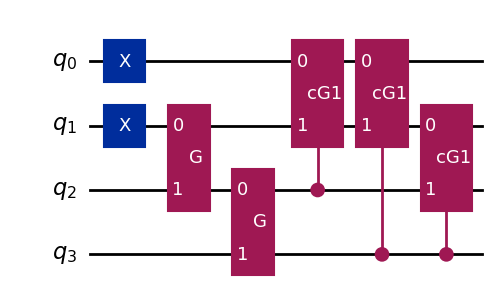

In [2]:
def ansatz(params, method="FCI"):
    qc = QuantumCircuit(Norb)
    # HF
    qc.x(0)
    qc.x(1)
    ## FCI
    if method == "FCI":
        qc.append(G_gate(params[0]), [1, 2])
        qc.append(G_gate(params[1]), [2, 3])
        qc.append(cG1_gate(params[2]), [2, 0, 1])
        qc.append(cG1_gate(params[3]), [3, 0, 1])
        qc.append(cG1_gate(params[4]), [3, 1, 2])        
    return qc

params = np.random.rand(5) * np.pi 
params = params_exact

qc = ansatz(params)
qc.draw(output='mpl')

次に、用意した回路から、各状態のstatevectorを計算してみよう。

なお、statevectorのときはmeasurementをいれていると、確定した一つの状態になってしまう。
回路を作り直すか、`qc.remove_final_measurements()`などを実行しよう。

In [3]:
from qiskit.quantum_info import Statevector

state_vector = Statevector.from_instruction(qc)
state_vector

Statevector([0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j,
             9.71213909e-01+0.j, 0.00000000e+00+0.j, 1.81939134e-01+0.j,
             9.81735082e-02+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j,
             9.81721942e-02+0.j, 6.36069907e-02+0.j, 0.00000000e+00+0.j,
             1.78892924e-02+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j,
             8.86822061e-18+0.j],
            dims=(2, 2, 2, 2))


In [4]:
state_vector.draw("latex")

<IPython.core.display.Latex object>

In [5]:
print(evecs[:,0])

[0.97121327 0.18194077 0.09817385 0.09817385 0.06360816 0.01789242]


## ハミルトニアンの表現


Qiskitの場合、ビット列やPaulistringは右側から、indexの若いqubitに対応することに注意が必要となる。

演算子のpauli stringが`IXII`のとき、`X`が作用するのは、0から数えて1番目のqubit...としたいところだが、
Qiskitでは、回路(qubit)の上(indexが若い方)から下をビット列の下位ビットから割り当てるので、`X`が作用するのは2番目のqubitになる。

In [6]:
from qiskit.quantum_info import SparsePauliOp

SPEs = Hamil.epsilon

#observable = SparsePauliOp.from_list([("ZIII", 1.0), ("IIIZ", 1.0), ("IIZZ", 1.0)])
# Hamiltonianを使う場合
pauli_list = [ ]
obs = [ ]
coeffs = [ ]

# I term
coeff = 0.0
op = "I" * Norb
for i in range(Norb):
    coeff += 0.5 * ( SPEs[i] - Hamil.gval ) 
obs += [op]
coeffs += [coeff]
# -Zp term
for i in range(Norb):
    op = "I" * Norb
    op = op[:i] + "Z" + op[i+1:]
    coeff = -0.5 * ( SPEs[i] - Hamil.gval )

    op = op[::-1]
    obs += [op]
    coeffs += [coeff]
# XX+YY term
for i in range(Hamil.Norb):
    for j in range(i+1, Hamil.Norb):
        factor = - Hamil.gval / 2
        op = "I" * Norb
        op = op[:i] + "X" + op[i+1:j] + "X" + op[j+1:]
        op = op[::-1]
        obs += [op]
        coeffs += [ factor ]
        op = "I" * Norb
        op = op[::-1]
        op = op[:i] + "Y" + op[i+1:j] + "Y" + op[j+1:]
        obs += [op]
        coeffs += [ factor ]

hamiltonian_op = SparsePauliOp(obs, coeffs)
hamiltonian_op

SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIXX', 'YYII', 'IXIX', 'YIYI', 'XIIX', 'YIIY', 'IXXI', 'IYYI', 'XIXI', 'IYIY', 'XXII', 'IIYY'],
              coeffs=[ 5.34 +0.j,  0.165+0.j, -0.835+0.j, -1.835+0.j, -2.835+0.j, -0.165+0.j,
 -0.165+0.j, -0.165+0.j, -0.165+0.j, -0.165+0.j, -0.165+0.j, -0.165+0.j,
 -0.165+0.j, -0.165+0.j, -0.165+0.j, -0.165+0.j, -0.165+0.j])

## 回路によるハミルトニアンの期待値の測定

期待値計算にはEstimatorを用いる。
QuantumComputingの章などで実装したような、pauli stringに対応した各項の期待値を計算してくれる。

In [7]:
from qiskit.primitives import StatevectorEstimator

estimator = StatevectorEstimator()
job = estimator.run([(qc, hamiltonian_op,)])
results = job.result()
E_meas = results[0].data.evs
print("E_meas: ", E_meas, "Egs_exact: ", Egs_exact, "diff.", E_meas - Egs_exact)

E_meas:  1.1898518352304346 Egs_exact:  1.1898518351360725 diff. 9.436207371038563e-11


厳密解を再現できた。上ではtranspileしなかったが、実機に応じたマッピングをしたい場合、
noisy simulatorを試したい場合などはtranspileが必要になる。

ノイズなしの場合のshot 測定

Counts(ideal): {'0011': 9460, '0101': 306, '0110': 94, '1010': 42, '1001': 94, '1100': 4}


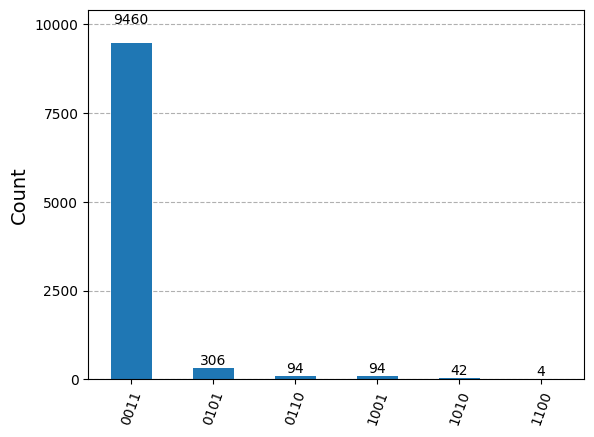

In [8]:
from qiskit_aer.primitives import SamplerV2
sampler = SamplerV2()

qc = ansatz(params)
qc.measure_all()
tqc = transpile(qc.decompose())

# Construct an ideal simulator with SamplerV2
sampler = SamplerV2()
job = sampler.run([tqc], shots=10000)

result_ftqc = job.result()
counts_ftqc = result_ftqc[0].data.meas.get_counts()
print('Counts(ideal):', counts_ftqc)

plot_histogram(counts_ftqc)

ノイズありの場合

粒子数を保存しない結果が現れることを確認しよう。

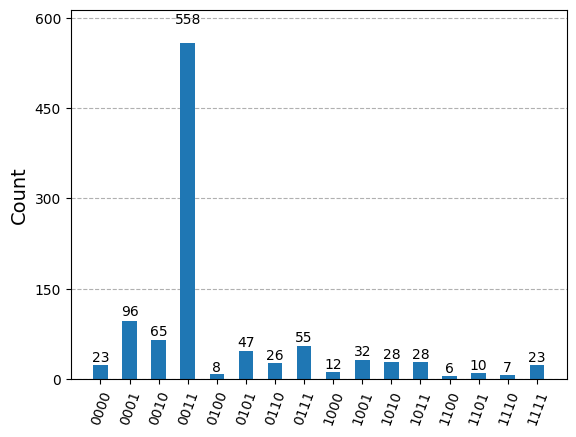

In [9]:
from qiskit_ibm_runtime.fake_provider import FakeQuebec
from qiskit_aer import AerSimulator

device_backend = FakeQuebec()
sim_quebec = AerSimulator.from_backend(device_backend)

qc = ansatz(params)
qc.measure_all()
tqc = transpile(qc, sim_quebec)

result_noise = sim_quebec.run(tqc, shot=10**4).result()
counts_noise = result_noise.get_counts(0)
plot_histogram(counts_noise)

In [10]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import Estimator as AerEstimator

device = FakeManilaV2()
coupling_map = device.coupling_map
noise_model = NoiseModel.from_backend(device)

noisy_estimator = AerEstimator(
    backend_options={
        'method': 'density_matrix',
        'coupling_map': coupling_map,
        'noise_model': noise_model,
    },
    run_options={'shots': 1024}
)

qc = ansatz(params_exact)
qc.remove_final_measurements()
noisy_expval = noisy_estimator.run([qc], [hamiltonian_op]).result().values[0]
print(f'{noisy_expval=}')


noisy_expval=2.0027050781249995


ノイズの影響で粒子数を破る配位が生成されていたり、エネルギー推定がうまく行っていない事がわかる。
このような場合は、error mitigationを行ったり、post-selectionで粒子数を保存するような配位で期待値を計算するなどの工夫が必要になる。

## 実時間発展演算子の作成

幾つかの量子アルゴリズムでは、Hamiltonianによる実時間発展$U(t) = e^{-iHt}$を用いることになる。

Qiskitには`PauliEvolutionGate`があり、これにより実時間発展演算子を作成することができる。
マイナス符号がdefaultなので、位相推定による期待値計算などの際にはそのことを考慮する。

演算子をexponentiateする際は、Suzuki-Trotter分解などを用いることになるが、一般にはこれは近似である。
以下には、First-order Suzuki-Trotter分解を用いた例を示す。

$$
\exp\left( \sum_i i c_i \hat{H}_i \right) \approx \left( \prod_i \exp(i c_i \hat{H}_i/r) \right)^r
$$

In [11]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter

time = 1.e-1
trotter_steps = 30
op = PauliEvolutionGate(hamiltonian_op, time, synthesis=SuzukiTrotter(order=1,reps=trotter_steps))
U = op.definition
U.name = "$U$"

また、制御ビットを指定して制御ユニタリ演算子を作成することもできる(例は、続く節で示す)。

では、実時間発展演算子に現れる各項はどのような形で表現され、どのように回路にencodeされるのか。

Pairing Hamiltonianの場合は、Jordan-Wigner変換の結果がシンプルなため、たかだか$I, Z_i, Z_iZ_j, X_iX_j, Y_iY_j$の項が現れるだけだが、
一般のハミルトニアンの各項は、Pauli演算子$\{ I, X, Y, Z \}$の直積で表現される。

$$
\hat{H}_i = c_i ( \sigma_1 \otimes \sigma_2 \otimes \cdots \otimes \sigma_n )
$$

$n$量子ビットの系において、$c_i$は実数、$\sigma_j \in \{ I, X, Y, Z \}$は$j$番目の量子ビットに作用するPauli演算子を表す。

これらの演算は、はしご状のCNOTと各Pauli演算子に対応する基底変換で系統的にエンコードできる。例として以下の2つを考えよう。
$R_z(\theta) = \exp(-i \theta/2 Z)$と、係数に注意して、自前の実装とPauliEvolutionGateを用いた実装を比較してみる。

- (a). $\exp(-i \theta (Z_1 \otimes Z_2 \otimes Z_3))$
- (b). $\exp(-i \theta (X_1 \otimes Y_2 \otimes Z_3))$

自前回路, PauliEvolutionGateの順に回路とstatevectorを表示する。

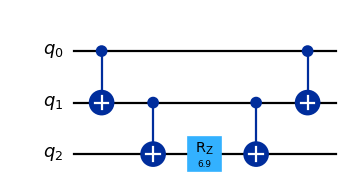

<IPython.core.display.Latex object>

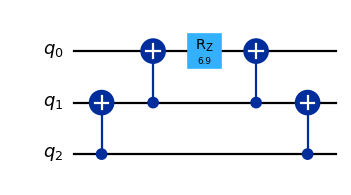

<IPython.core.display.Latex object>

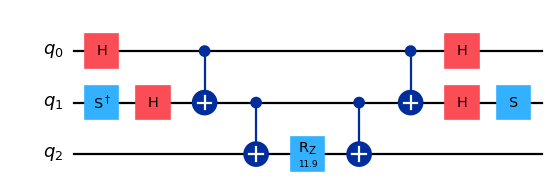

<IPython.core.display.Latex object>

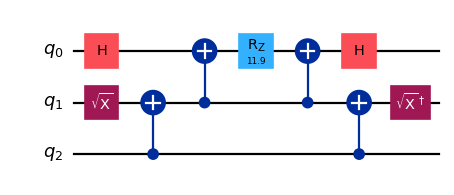

<IPython.core.display.Latex object>

In [12]:
theta = np.random.rand() * 2 * np.pi
qc_a = QuantumCircuit(3)
qc_a.cx(0, 1); qc_a.cx(1, 2)
qc_a.rz(theta*2, 2)
qc_a.cx(1, 2); qc_a.cx(0, 1)

U = SparsePauliOp(["ZZZ"], [1.0])
U_a = PauliEvolutionGate(U, theta, synthesis=SuzukiTrotter(order=1, reps=1))
qc_a_paulievol = QuantumCircuit(3)
qc_a_paulievol.append(U_a, range(3))
qc_a_paulievol = qc_a_paulievol.decompose()

sv_a = Statevector.from_instruction(qc_a)
sv_a_paulievol = Statevector.from_instruction(qc_a_paulievol)

theta = np.random.rand() * 2 * np.pi
qc_b = QuantumCircuit(3)
qc_b.h(0); qc_b.sdg(1); qc_b.h(1)
qc_b.cx(0, 1); qc_b.cx(1, 2)
qc_b.rz(theta*2, 2)
qc_b.cx(1, 2); qc_b.cx(0, 1)
qc_b.h(0); qc_b.h(1); qc_b.s(1)

U = SparsePauliOp(["ZYX"], [1.0])
U_b = PauliEvolutionGate(U, theta, synthesis=SuzukiTrotter(order=1, reps=1))
qc_b_paulievol = QuantumCircuit(3)
qc_b_paulievol.append(U_b, range(3))
qc_b_paulievol = qc_b_paulievol.decompose()

sv_b = Statevector.from_instruction(qc_b)
sv_b_paulievol = Statevector.from_instruction(qc_b_paulievol)

display(qc_a.draw(output='mpl', scale=0.8), sv_a.draw(output='latex'))
display(qc_a_paulievol.draw(output='mpl', scale=0.8),sv_a_paulievol.draw(output='latex'))

display(qc_b.draw(output='mpl', scale=0.8), sv_b.draw(output='latex'))
display(qc_b_paulievol.draw(output='mpl', scale=0.8), sv_b_paulievol.draw(output='latex'))


## Hadamard test

[9.5.2節](https://sotayoshida.github.io/Lecture_SummerSchool2025/notebooks/QuantumComputing.html#hadamard-test)
で紹介したHadamard testを実装する。

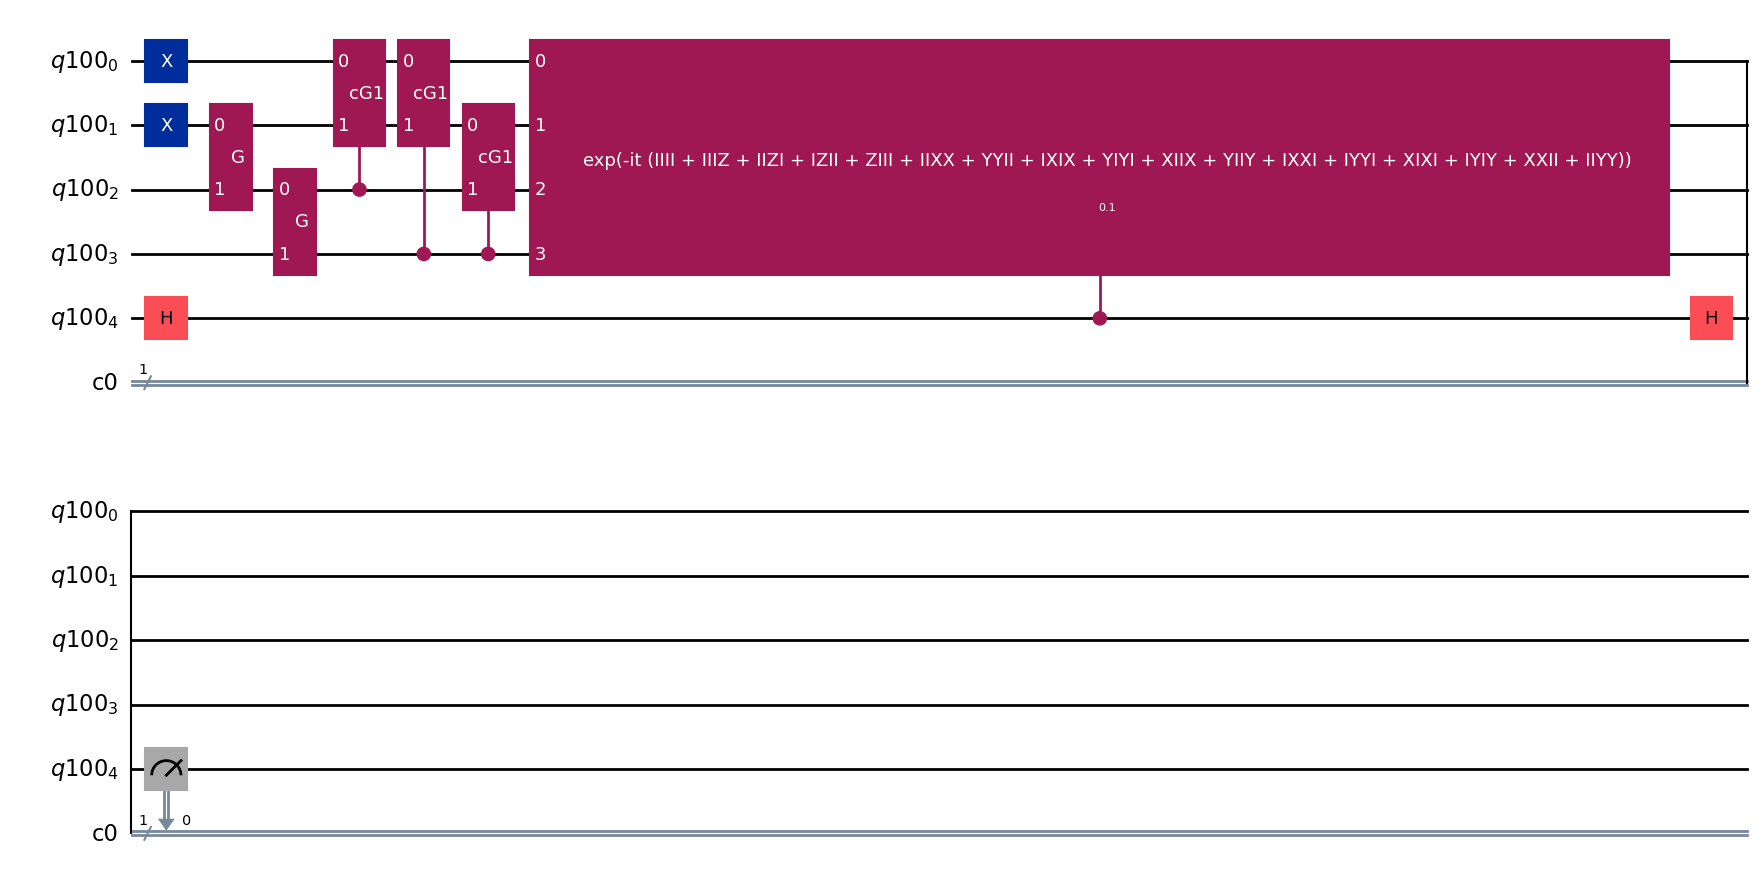

In [13]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

qr_Hadamard = QuantumRegister(Norb+1)
cr_Hadamard = ClassicalRegister(1)
qc_Hadamard = QuantumCircuit(qr_Hadamard, cr_Hadamard)

# State preparation
params = params_exact
psi = ansatz(params)
qc_Hadamard.x(0)
qc_Hadamard.x(1)
qc_Hadamard.append(G_gate(params[0]), [1, 2])
qc_Hadamard.append(G_gate(params[1]), [2, 3])
qc_Hadamard.append(cG1_gate(params[2]), [2, 0, 1])
qc_Hadamard.append(cG1_gate(params[3]), [3, 0, 1])
qc_Hadamard.append(cG1_gate(params[4]), [3, 1, 2])

# Hadamard on ancilla
qc_Hadamard.h(4)
# controlled-U
U = PauliEvolutionGate(hamiltonian_op, time, synthesis=SuzukiTrotter(order=1,reps=trotter_steps))
cU = U.control(1)
qc_Hadamard.append(cU, [4, 0, 1, 2, 3])
# Hadamard on ancilla and measurement
qc_Hadamard.h(4)

# for measurement
qc_1 = qc_Hadamard.copy()
qc_1.measure(4, 0)

# for statevector
qc_2 = qc_Hadamard.copy()

# Draw the circuit
qc_1.draw(output='mpl')

測ってみよう

In [14]:
qc_1 = qc_1.decompose()

n_shot = 10**5
sim = AerSimulator()
counts = sim.run(qc_1, shots=n_shot).result().get_counts()
counts

p0 = counts.get('0', 0) / n_shot
p1 = counts.get('1', 0) / n_shot
print(f'p0={p0}, p1={p1}')

p0=0.99649, p1=0.00351


$$
\begin{align}
P(0) & =  \left| \frac{1 + e^{iEt}}{2} \right|^2 = \frac{1 + \cos(Et)}{2} \\
P(1) & =  \left| \frac{1 - e^{iEt}}{2} \right|^2 = \frac{1 - \cos(Et)}{2} \\
\end{align}
$$

なので、この結果からground stateのエネルギーを推定することができる。

In [15]:
Et = p0 - p1
E = np.arccos(Et) / time
print("E:", E, "Egs_exact: ", Egs_exact, "diff.", E - Egs_exact)

E: 1.1855993261018105 Egs_exact:  1.1898518351360725 diff. -0.0042525090342619976


Statevectorの場合は...$t$などを変えない限りは実行ごとに同じ結果になる。

In [16]:
qc2 = qc_2.decompose()

state_vector = Statevector.from_instruction(qc2)
sv_arr = np.array(state_vector)

p0 = p1 = 0
for k in range(2**(1+Norb)):
    ancilla = k >> Norb
    if ancilla == 0:
        p0 += sv_arr[k] * np.conj(sv_arr[k])
    else:
        p1 += sv_arr[k] * np.conj(sv_arr[k])
print("p0:", p0, "p1:", p1)
Et = p0 - p1
E = np.real( np.arccos(Et) / time )
print("E:", np.real(E), "Egs_exact: ", Egs_exact, "diff.", E - Egs_exact)

p0: (0.9964647046884788+0j) p1: (0.003535295311496347+0j)
E: 1.189868780810853 Egs_exact:  1.1898518351360725 diff. 1.6945674780499687e-05


## 量子位相推定(QPE)

続いて、量子位相推定(QPE)を実装する。

### 簡単な例

いきなりHamiltonianの期待値を求めようとすると間違えたりするのでまずは簡単な例から。

ターゲット量子ビットは1~2個にして、比較的簡単な状態作成&制御ユニタリ演算子を作成しよう。


**例1: $U=CP(\phi)$で1ターゲット量子ビットをP-gateの固有状態にとる場合**


$P(\phi) = \ket{0}\bra{0} + e^{i\phi}\ket{1}\bra{1}$なので、
$\ket{\psi} = \ket{1}$を用意すれば、推定したい位相は$\phi/2\pi$になる。

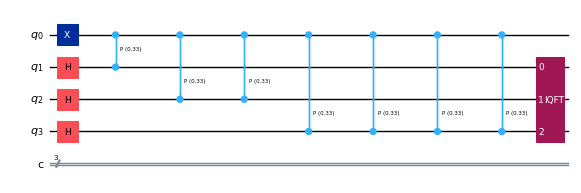

In [17]:
from qiskit.circuit.library.standard_gates import PhaseGate
from qiskit.circuit.library import QFT

def circuit_ex1(n_ancilla, theta, measure=True, using_qiskit=True):
    qc = QuantumCircuit(n_ancilla + 1, n_ancilla)
    register_ancilla = range(1, 1+n_ancilla)
    register_target = range(1)
    # State preparation
    qc.x(register_target) # |1>

    # Hadamard on ancilla
    for qubit in register_ancilla:
        qc.h(qubit)
    # Controlled-U operations
    repetitions = 1
    for counting_qubit in register_ancilla:
        for _ in range(repetitions):
            qc.cp(theta, counting_qubit, 0)
        repetitions *= 2
    
    # Inverse QFT
    qft_dagger = QFT(n_ancilla, inverse=True)   
    qc.append(qft_dagger, register_ancilla)

    if measure:
        qc.measure(register_ancilla, range(n_ancilla))
    return qc

n_ancilla = 3
theta = 0.33 
qc_QPE = circuit_ex1(n_ancilla, theta, measure=False, using_qiskit=True)
qc_QPE.draw(output='mpl', scale=0.5)

In [18]:
n_ancilla = 10
theta = np.pi / 8

qc_QPE = circuit_ex1(n_ancilla, theta, measure=False, using_qiskit=True)
qc_QPE = qc_QPE.decompose()#.decompose()
state_vector = Statevector.from_instruction(qc_QPE)

idxs = np.argsort(np.abs(state_vector.data))[::-1][:3]
print("top3: ", idxs)
for idx in idxs:
    bitstr_from_idx = format(idx, f'0{n_ancilla+1}b')
    bit_ancilla = bitstr_from_idx[:n_ancilla]
    estimated = int(bit_ancilla, 2)/(2**n_ancilla) * 2 * np.pi
    print("idx", idx, "estimated_theta", estimated)
print("theta_exact", theta, " 2pi/2^n", 2*np.pi/2**n_ancilla)

top3:  [129 127 131]
idx 129 estimated_theta 0.39269908169872414
idx 127 estimated_theta 0.3865631585471816
idx 131 estimated_theta 0.3988350048502667
theta_exact 0.39269908169872414  2pi/2^n 0.006135923151542565


推定したい位相が(たまたま)$2\pi/2^m$のときは,$m$個のancillaを用意すれば、理想的には位相を厳密に推定できる。
それ以外の場合は$2\pi/2^n$の精度で推定することになる。
さらに実機で測る場合はノイズの影響もあり古典計算機で行うような倍精度で推定することは現状、困難である。

In [19]:
# shot measurement
qc_QPE = circuit_ex1(n_ancilla, theta, measure=True, using_qiskit=True)
qc_QPE = qc_QPE.decompose().decompose().decompose()

n_shot = 1024
sim = AerSimulator()
counts = sim.run(qc_QPE, shots=n_shot).result().get_counts()

bitstrs = [ ]
x = []
y = []
for k, v in counts.items():
    bitstrs += [k]
    x += [int(k, 2)/(2**n_ancilla) ]
    y += [v]
idx = np.argmax(y)
theta_estimated = x[idx]*2*np.pi
print("idx", idx, "bitstr", bitstrs[idx], "theta", theta_estimated, "theta_exact", theta, "diff", theta_estimated - theta)

idx 0 bitstr 0001000000 theta 0.39269908169872414 theta_exact 0.39269908169872414 diff 0.0


**例2: 数演算子の時間発展を考える。**

$\ket{\psi} = \ket{11} $

$U = \exp{(i t (I_0-Z_0) \otimes (I_1-Z_1))}$

$ (I_0-Z_0) \otimes (I_1-Z_1) \ket{\psi} = 4 \ket{11}$なので、
$ \exp{(i t (I_0-Z_0) \otimes (I_1-Z_1))} \ket{\psi} = \exp{(i 4 t)} \ket{11}$となり、$\ket{\psi}$は$U$の固有状態、固有値は$e^{i4t}$である。

したがって、位相推定で得た$\theta$から$2\pi \theta / t$を計算して、$4$を得ることができれば成功である。

In [20]:
time = 0.1234
trotter_steps = 50
obs = [ "II", "ZI", "IZ", "ZZ"]
coeffs = [ -1.0, 1.0, 1.0, -1.0]
org_op = SparsePauliOp(obs, coeffs)
unitary = PauliEvolutionGate(org_op, time, label="U", synthesis=SuzukiTrotter(order=1, reps=trotter_steps))

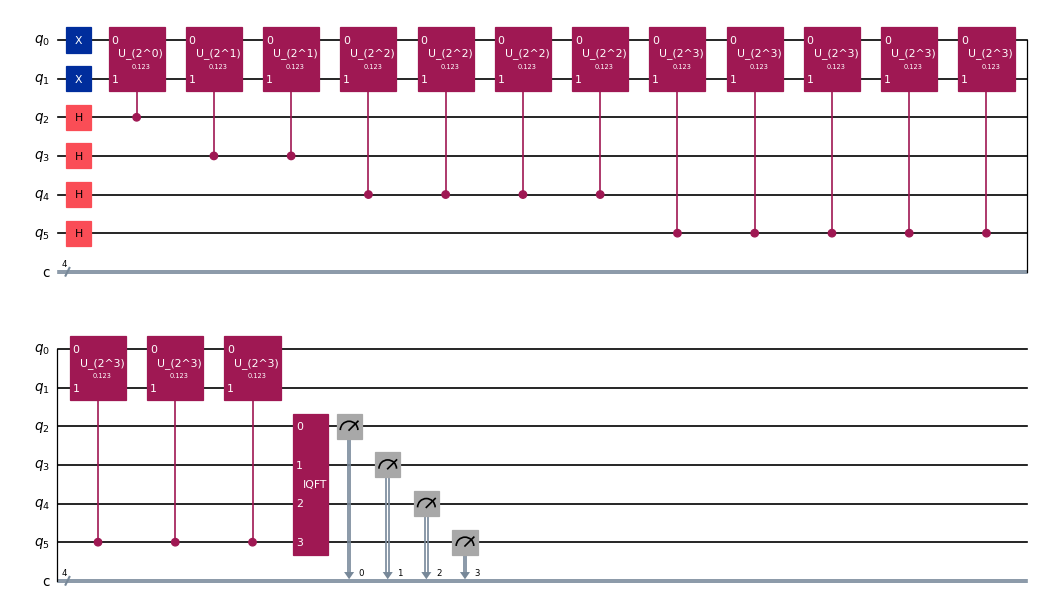

In [21]:
def make_QPE_circuit_ex2(n_ancilla, n_psi, unitary, measure=True):
    qc_QPE = QuantumCircuit(n_ancilla + n_psi, n_ancilla)
    register_ancilla = range(n_psi, n_psi+n_ancilla)
    register_target = range(n_psi)

    # State preparation
    qc_QPE.x(0)
    qc_QPE.x(1)

    # Hadamard on ancilla
    for qubit in register_ancilla:
        qc_QPE.h(qubit)
    # Controlled-U operations
    repetitions = 1
    for counting_qubit in register_ancilla:
        for _ in range(repetitions):
            unitary.label = f"U_(2^{int(np.log2(repetitions))})"
            unitary_ctrl = unitary.control(1)
            qc_QPE.append(unitary_ctrl, [counting_qubit] + list(register_target))            
        repetitions *= 2
    # Inverse QFT
    qft_dagger = QFT(n_ancilla, inverse=True)   
    qc_QPE.append(qft_dagger, register_ancilla)
    
    if measure:
        qc_QPE.measure(register_ancilla, range(n_ancilla))
    return qc_QPE

n_ancilla = 4
n_psi = 2
qc_QPE = make_QPE_circuit_ex2(n_ancilla, n_psi, unitary)
qc_QPE.draw(output='mpl', scale=0.6)

In [22]:
# Statevector
n_ancilla = 8
n_psi = 2

qc_QPE = make_QPE_circuit_ex2(n_ancilla, n_psi, unitary, measure=False)
qc_QPE = qc_QPE.decompose()#.decompose()
state_vector = Statevector.from_instruction(qc_QPE)

In [23]:
idx = np.argmax(np.abs(state_vector.data))
bitstr_from_idx = format(idx, f'0{n_ancilla+n_psi}b')
bit_ancilla = bitstr_from_idx[:n_ancilla]
theta= int(bit_ancilla, 2)/(2**n_ancilla) 
lambda_t = theta * 2 * np.pi / time 
print("idx", idx, "bit_ancilla", bit_ancilla, 
      "theta", theta, "lambda=2pitheta/time", lambda_t, " 2pi/2^n", 2*np.pi/2**n_ancilla)

idx 83 bit_ancilla 00010100 theta 0.078125 lambda=2pitheta/time 3.977908039897935  2pi/2^n 0.02454369260617026


### Pairing HamilaonitnのQPE計算

次に、pairing Hamiltonianの場合を考える

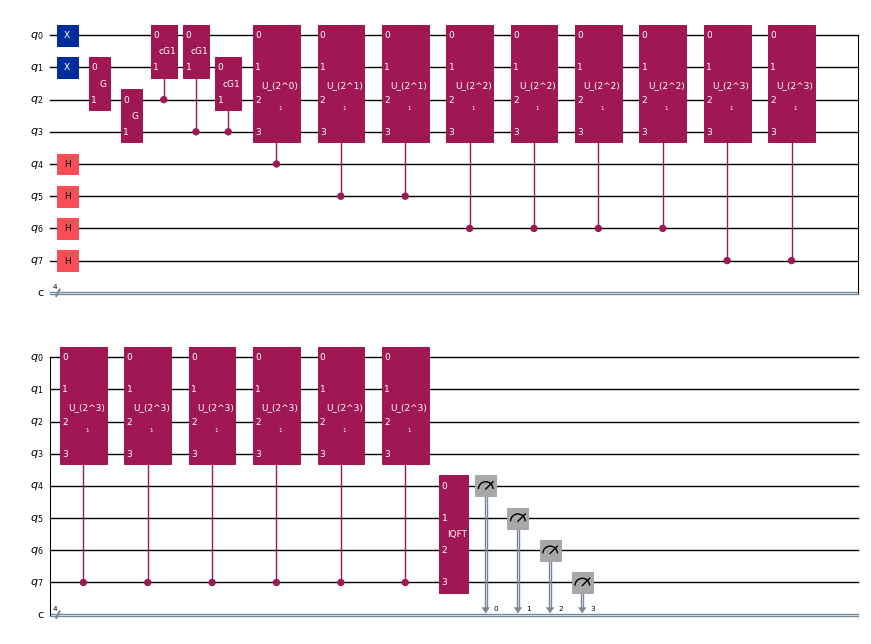

In [24]:
from qiskit.circuit.library import QFT
from qiskit.circuit.library import PhaseEstimation # will be deprecated
from qiskit.circuit.library import phase_estimation

def state_preparation(qc, params, method="FCI"):
    if Norb != 4:
        raise ValueError("This function is only for Norb=4")
    # HF
    qc.x(0)
    qc.x(1)
    ## FCI
    if method == "FCI":
        qc.append(G_gate(params[0]), [1, 2])
        qc.append(G_gate(params[1]), [2, 3])
        qc.append(cG1_gate(params[2]), [2, 0, 1])
        qc.append(cG1_gate(params[3]), [3, 0, 1])
        qc.append(cG1_gate(params[4]), [3, 1, 2])
    return qc

def make_QPE_circuit(n_ancilla, Norb, params_psi, measure=False):
    qc_QPE = QuantumCircuit(n_ancilla + Norb, n_ancilla)
    register_ancilla = range(Norb, Norb+n_ancilla)
    register_target = range(Norb)
    # State preparation
    state_preparation(qc_QPE, params_psi)

    # Hadamard on ancilla
    for qubit in register_ancilla:
        qc_QPE.h(qubit)
    # Controlled-U operations
    U = PauliEvolutionGate(hamiltonian_op, time, synthesis=SuzukiTrotter(order=1,reps=trotter_steps))
    repetitions = 1
    for counting_qubit in register_ancilla:
        for _ in range(repetitions):
            U.label = f"U_(2^{int(np.log2(repetitions))})"
            U_ctrl = U.control(1)
            qc_QPE.append(U_ctrl, [counting_qubit] + list(register_target))            
        repetitions *= 2
    # Inverse QFT
    qft_dagger = QFT(n_ancilla, inverse=True)
    qc_QPE.append(qft_dagger, register_ancilla)

    if measure:
        qc_QPE.measure(register_ancilla, range(n_ancilla))
    return qc_QPE

n_ancilla = 4 
params_psi = params_exact
time = 1.0

qc_QPE = make_QPE_circuit(n_ancilla, Norb, params_psi, measure=True)
qc_QPE.draw(output='mpl', scale=0.5)

In [25]:
params_psi = params_exact
n_ancilla = 6
time = - 1.0
trotter_steps = 20

In [26]:
# shot measurement
qc_QPE = make_QPE_circuit(n_ancilla, Norb, params_psi, measure=True)
qc_QPE = qc_QPE.decompose().decompose()

n_shot = 1024
sim = AerSimulator()
counts = sim.run(qc_QPE, shots=n_shot).result().get_counts()

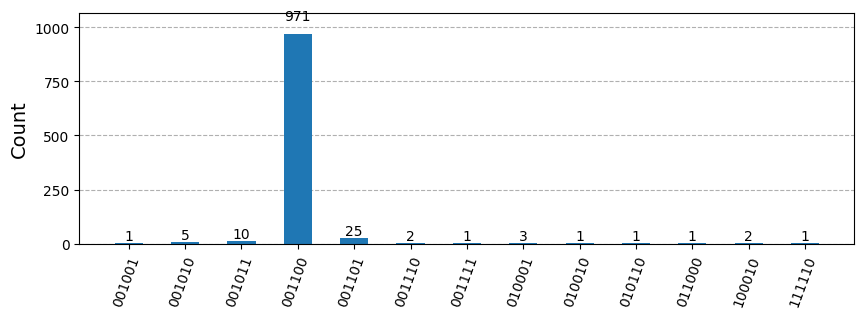

In [27]:
plot_histogram(counts,figsize=(10, 3))

In [28]:
float_from_bitstr = lambda bitstr: int(bitstr, 2)/(2**n_ancilla) * 2 * np.pi / -time
E_estimated = float_from_bitstr(counts.most_frequent())
print(f"E_estimated: {E_estimated:.8f} Egs_exact: {Egs_exact:.8f} diff. {E_estimated - Egs_exact:.2e}")

E_estimated: 1.17809725 Egs_exact: 1.18985184 diff. -1.18e-02


### Statevector



In [35]:
qc_QPE = make_QPE_circuit(n_ancilla, Norb, params_psi, measure=False)
qc_QPE.save_statevector()

sim = AerSimulator(method='statevector')
tqc = transpile(qc_QPE, sim)
print("transpiled!")
result = sim.run(tqc).result()


transpiled!


In [37]:
psi_final = result.get_statevector(tqc)

In [ ]:
probs = psi_final.probabilities_dict(range(Norb + n_ancilla))
list_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)
for bitstring_whole, p in list_probs:
    
    if p < 1e-3:
        continue
    print(f"bitstring whole: {bitstring_whole} prob.: {p:.6f}")

bitstring whole: 0011000011 prob.: 0.896477
bitstring whole: 0011000101 prob.: 0.031468
bitstring whole: 1011000011 prob.: 0.017672
bitstring whole: 1101000011 prob.: 0.010790
bitstring whole: 0011000110 prob.: 0.009044
bitstring whole: 0011001001 prob.: 0.009044
bitstring whole: 0011001010 prob.: 0.004527
bitstring whole: 0111000011 prob.: 0.003867
bitstring whole: 0101000011 prob.: 0.003025
bitstring whole: 1111000011 prob.: 0.001652
bitstring whole: 1001000011 prob.: 0.001404
